In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip '/content/drive/MyDrive/Group k.zip'

Streaming output truncated to the last 5000 lines.
  inflating: Group k/Alf_Isolated/AHCR_00033_Alf_Isolated_15.jpg  
  inflating: Group k/Alf_Isolated/AHCR_00033_Alf_Isolated_6.jpg  
  inflating: Group k/Alf_Isolated/AHCR_00033_Alf_Isolated_7.jpg  
  inflating: Group k/Alf_Isolated/AHCR_00034_Alf_Isolated_14.jpg  
  inflating: Group k/Alf_Isolated/AHCR_00034_Alf_Isolated_15.jpg  
  inflating: Group k/Alf_Isolated/AHCR_00034_Alf_Isolated_6.jpg  
  inflating: Group k/Alf_Isolated/AHCR_00034_Alf_Isolated_7.jpg  
  inflating: Group k/Alf_Isolated/AHCR_00035_Alf_Isolated_14.jpg  
  inflating: Group k/Alf_Isolated/AHCR_00035_Alf_Isolated_15.jpg  
  inflating: Group k/Alf_Isolated/AHCR_00035_Alf_Isolated_6.jpg  
  inflating: Group k/Alf_Isolated/AHCR_00035_Alf_Isolated_7.jpg  
  inflating: Group k/Alf_Isolated/AHCR_00036_Alf_Isolated_14.jpg  
  inflating: Group k/Alf_Isolated/AHCR_00036_Alf_Isolated_15.jpg  
  inflating: Group k/Alf_Isolated/AHCR_00036_Alf_Isolated_6.jpg  
  inflating: Group

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
img_width, img_height = 150, 150
data_dir = "/content/Group k"

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

img_width, img_height = 150, 150
data_dir = "/content/Group k"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir)) 

    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):  
            for img_file in os.listdir(group_path):
                img_path = os.path.join(group_path, img_file)
                try:
                    img = tf.keras.preprocessing.image.load_img(
                        img_path, target_size=(img_width, img_height), color_mode='grayscale'
                    )
                    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                    images.append(img_array)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading image {img_file} in {group_name}: {e}")

    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

if len(images) == 0:
    raise ValueError("No images were loaded. Check the data directory and file paths.")

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(f"Training samples: {x_train.shape[0]}, Testing samples: {x_test.shape[0]}")
print(f"Number of classes: {num_classes}")


Training samples: 4479, Testing samples: 1120
Number of classes: 12


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


280/280 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.1495 - loss: 2.4301 - val_accuracy: 0.4893 - val_loss: 1.5570
Epoch 2/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.4099 - loss: 1.6805 - val_accuracy: 0.5295 - val_loss: 1.3949
Epoch 3/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.5605 - loss: 1.3033 - val_accuracy: 0.7304 - val_loss: 0.8040
Epoch 4/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.6239 - loss: 1.1513 - val_accuracy: 0.6982 - val_loss: 0.8721
Epoch 5/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.6583 - loss: 0.9693 - val_accuracy: 0.7527 - val_loss: 0.7060
Epoch 6/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6882 - loss: 0.8888 - val_accuracy: 0.8071 - val_loss: 0.6141
Epoch 7/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.7013 - loss: 0.8591 - val_accuracy: 0.7607 - val_loss: 0.7128
Epoch 8/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.7204 - loss: 0.7788 - val_accuracy

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9130 - loss: 0.2779
Train Accuracy: 85.51%
Test Accuracy: 91.79%


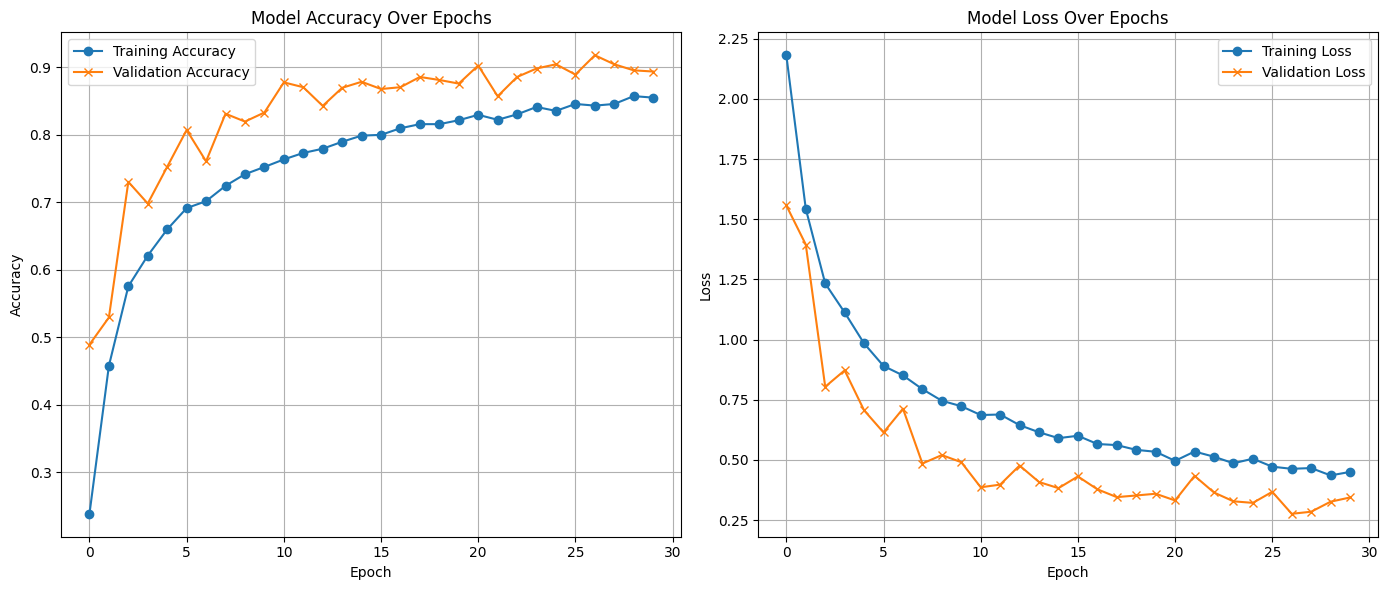

In [ ]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


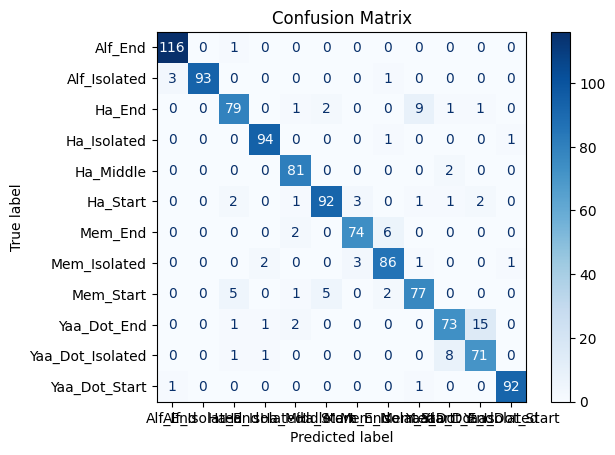

In [ ]:

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


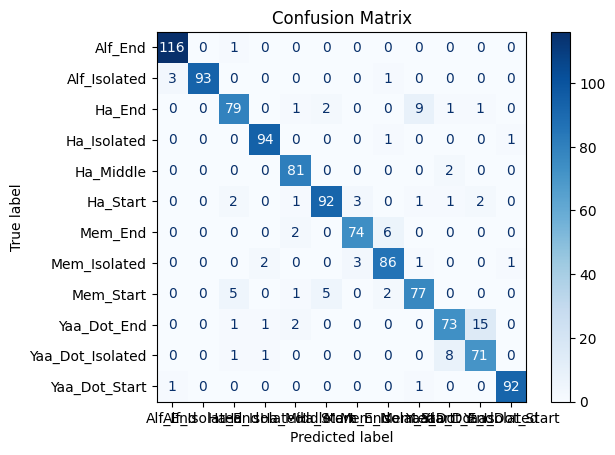

Number of incorrect predictions: 92


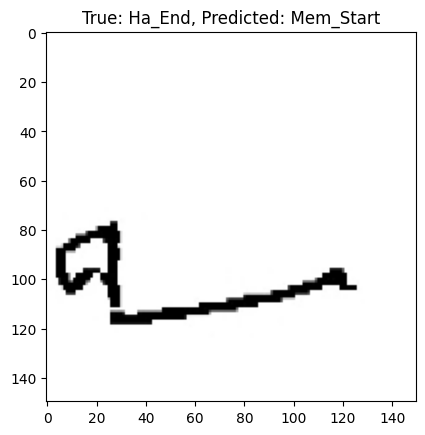

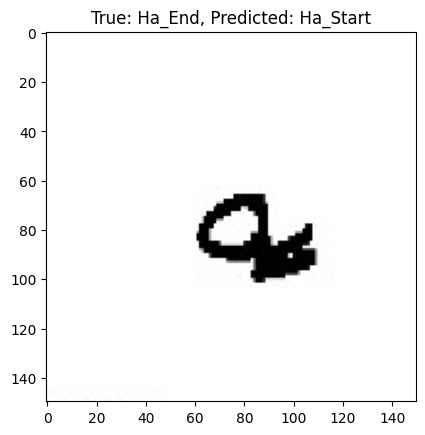

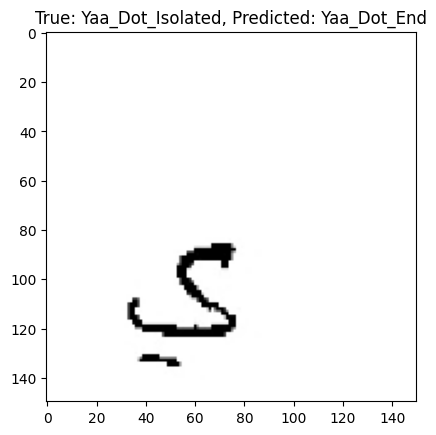

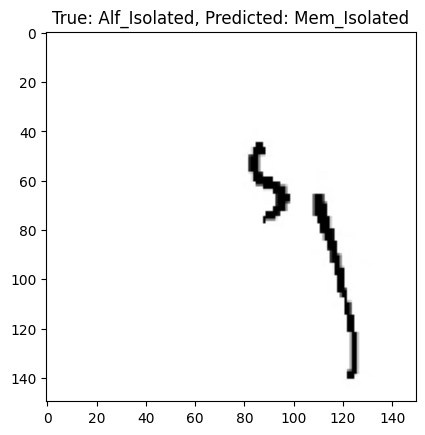

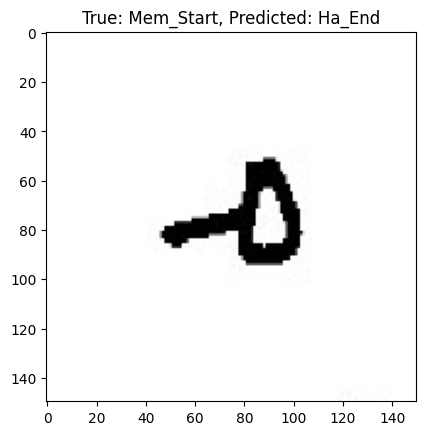

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### remove dropout and decrease epochs 

In [37]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [38]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=28,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/28


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


280/280 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.2448 - loss: 2.1754 - val_accuracy: 0.6116 - val_loss: 1.1555
Epoch 2/28
280/280 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.6351 - loss: 1.0891 - val_accuracy: 0.7464 - val_loss: 0.7412
Epoch 3/28
280/280 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.7574 - loss: 0.7506 - val_accuracy: 0.6670 - val_loss: 0.9624
Epoch 4/28
280/280 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.8050 - loss: 0.5965 - val_accuracy: 0.7964 - val_loss: 0.5765
Epoch 5/28
280/280 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.8130 - loss: 0.5453 - val_accuracy: 0.8143 - val_loss: 0.5606
Epoch 6/28
280/280 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.8301 - loss: 0.4956 - val_accuracy: 0.8848 - val_loss: 0.3838
Epoch 7/28
280/280 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.8573 - loss: 0.4461 - val_accuracy: 0.8554 - val_loss: 0.4517
Epoch 8/28
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.8710 - loss: 0.3885 - val_accuracy

In [40]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9125 - loss: 0.2669
Train Accuracy: 93.39%
Test Accuracy: 92.23%


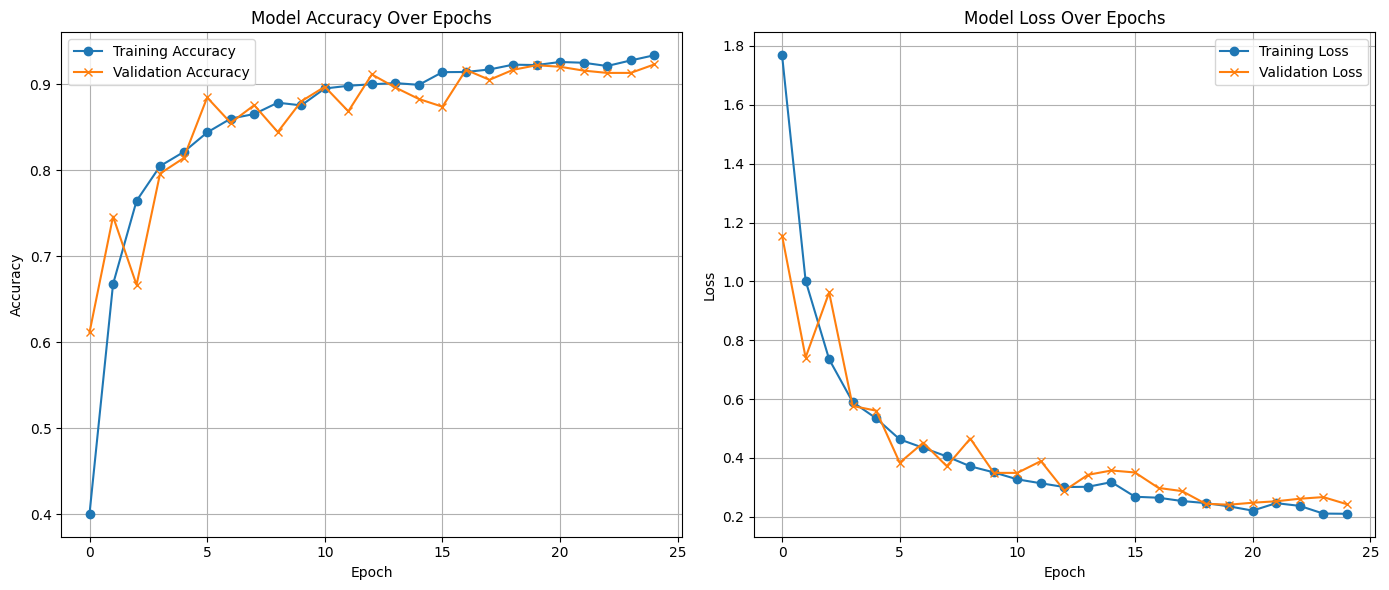

In [41]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


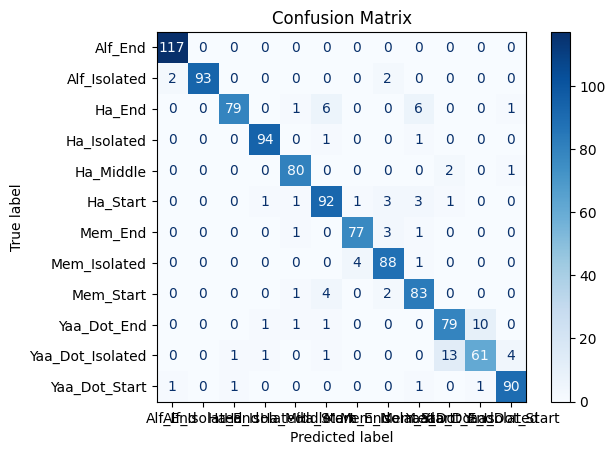

Number of incorrect predictions: 87


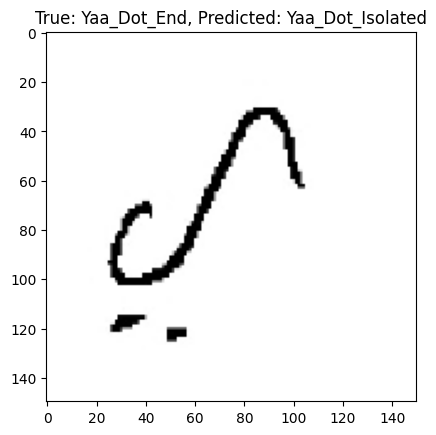

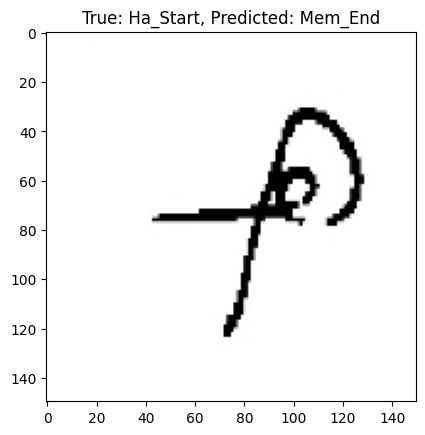

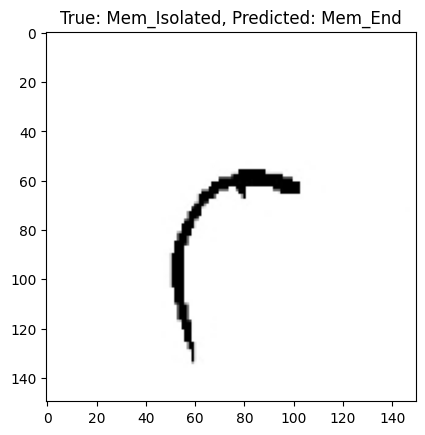

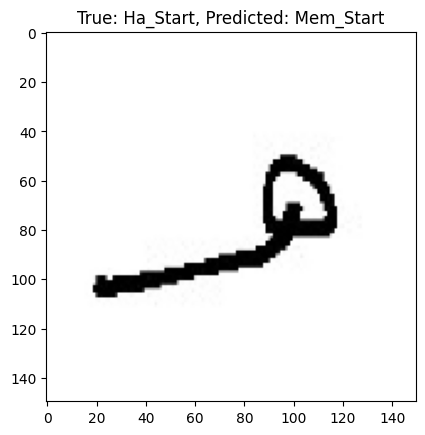

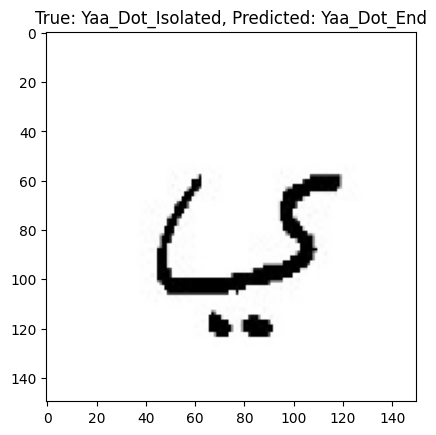

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


In [44]:
model.save("GrpK.keras")